# Spindown Analysis — 2026-07-02
Extracts the spin decay time τ from LES YAW/PIT monitor data using the Hilbert transform.

**Method:** bandpass filter → Hilbert transform → instantaneous frequency → exponential fit
**Model:** f(t) = A · exp(−t/τ)  (free spindown, no steady-state offset)

**Note on this run:** before the final drive-off (~11:57 AM EDT / ~17:34 UTC), the LES was
switched on and off several times, so the pre-drive-off region is messier than in
`spindown_20260603.ipynb`. Drive-off detection below takes the *last* time the 4 Hz
drive envelope was above threshold, which is robust to earlier toggling — but the DC
ramp-down baseline is computed from a short window immediately before that point
(not the whole pre-drive-off period) for the same reason. See Section 3.5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

/Users/mollywatts/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Switched 2026-07-09 to the wider extension-window export (gps 1467038898-1467064098,
# fetched 2026-07-08) so the true final drive-off / free decay is actually captured --
# the original window (1467041418-1467054018) cut off before spindown was visible.
# NOTE: only an IN1 tap was fetched for PIT in this wider window (no OUT), so PIT is
# now IN1 while it was OUT in the original window -- a channel change, not just a
# longer time span. Revisit if IN1 vs OUT turns out to matter for this analysis.
FILENAME_PIT = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_1467038898_1467064098.h5'
FILENAME_YAW = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467038898_1467064098.h5'

# Electrodes: known issue this run -- V1/V2 keep showing signal longer than
# V3/V4, i.e. the four channels do NOT turn off simultaneously. All four are
# loaded below so the true final drive-off can be taken as the LAST of the
# four to go quiet, not just V1.
ELECTRODE_FILES = {
    'V1': '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/Electrodes/Y1_RDS-OUTS_V1_OUT_DQ_1467038898_1467064098.h5',
    'V2': '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/Electrodes/Y1_RDS-OUTS_V2_OUT_DQ_1467038898_1467064098.h5',
    'V3': '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/Electrodes/Y1_RDS-OUTS_V3_OUT_DQ_1467038898_1467064098.h5',
    'V4': '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/Electrodes/Y1_RDS-OUTS_V4_OUT_DQ_1467038898_1467064098.h5',
}

# GPS → UTC: GPS epoch is Jan 6 1980; 18 leap seconds as of 2025
# NOTE: cymac1 GPS clock was measured +5836 s fast vs true GPS on 2026-06-03.
# That figure is a DIFFERENT day's measurement. For this 07-02 run, using a
# +3072 s offset instead (2026-07-09). Treat "cymac UTC" labels below as
# approximate, not wall-clock-exact.
# The tau fit itself does not depend on this offset -- drive-off is detected
# from the electrode envelopes directly in cymac GPS/data time, so the
# spindown result is unaffected either way. This offset only matters for
# lining plot axis labels up against wall-clock lab notes.
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

def dt_to_gps(dt):
    return dt.timestamp() - GPS_UNIX_OFFSET

# "True time" correction, applied on TOP of gps_to_dt/cymac UTC.
# +3072s for this 07-02 run.
TRUE_TIME_OFFSET_S = 3072  # cymac GPS clock runs this many seconds fast

def gps_to_true_dt(gps):
    """cymac GPS -> best-estimate true UTC for this run."""
    return gps_to_dt(gps - TRUE_TIME_OFFSET_S)

# Estimated final drive-off (11:57:00 AM EDT 2026-07-02 -> true GPS -> cymac GPS
# via the +3072s offset): cymac GPS ~= 1467046110 (~16:48:30 UTC cymac time).
# This is only a rough sanity-check overlay -- the true final drive-off is
# detected from the electrode envelopes below, not assumed from this estimate.
DRIVE_OFF_ESTIMATE_GPS = 1467046110

In [3]:
with h5py.File(FILENAME_PIT, 'r') as f:
    FS        = float(f.attrs['sample_rate'])
    gps_start = float(f.attrs['gps_start'])
    gps_end   = float(f.attrs['gps_end'])
    n_total   = f['data'].shape[0]

print(f"Rate:     {FS} Hz")
print(f"Samples:  {n_total:,}  ({n_total / FS / 3600:.2f} h)")
print(f"Start:    {gps_to_dt(gps_start)}")
print(f"End:      {gps_to_dt(gps_end)}")
print(f"Drive-off estimate within window? {gps_start <= DRIVE_OFF_ESTIMATE_GPS <= gps_end}")

Rate:     1024.0 Hz
Samples:  25,804,800  (7.00 h)
Start:    2026-07-02 14:48:00+00:00
End:      2026-07-02 21:48:00+00:00
Drive-off estimate within window? True


## 2. Overview: Full Time Series
Strided read (every 32nd sample → 32 Hz) for fast visual inspection across the full window.
Use this to see the on/off toggling period and the final spindown region, then set
`RING_START` / `RING_END` below.

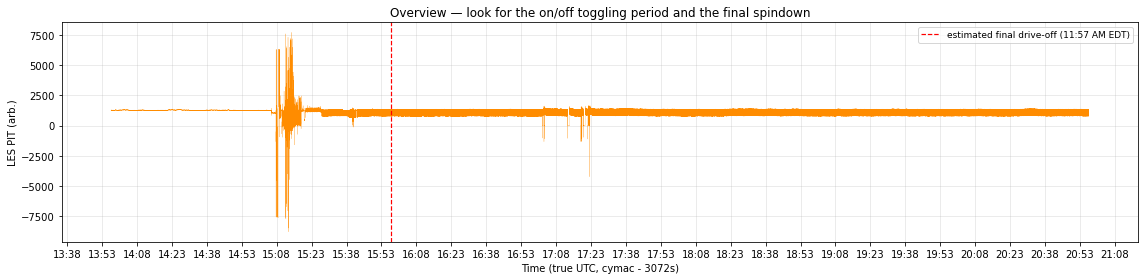

In [4]:
# Strided read — no anti-alias filter, for visual inspection only
STRIDE = 32  # 1024 Hz -> 32 Hz effective
t_ov, y_ov = [], []

with h5py.File(FILENAME_PIT, 'r') as f:
    segs = f['segments/gps_start'][:].astype(np.float64)
    idxs = f['segments/index_start'][:].astype(np.int64)
    lens = f['segments/length'][:].astype(np.int64)
    dset = f['data']
    for gps0, ix, n in zip(segs, idxs, lens):
        y_seg = dset[ix : ix + n : STRIDE].astype(np.float32)
        t_seg = gps0 + np.arange(len(y_seg)) * STRIDE / 1024.0
        t_ov.append(t_seg)
        y_ov.append(y_seg)

t_ov = np.concatenate(t_ov)
y_ov = np.concatenate(y_ov)

# Time axis shown in TRUE UTC (cymac GPS - TRUE_TIME_OFFSET_S = 3072 s), so this
# can be compared directly against wall-clock lab notes. cymac-time equivalents
# are still available via gps_to_dt() if needed.
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot([gps_to_true_dt(t) for t in t_ov], y_ov, linewidth=0.2, color='darkorange')
if gps_start <= DRIVE_OFF_ESTIMATE_GPS <= gps_end:
    ax.axvline(gps_to_true_dt(DRIVE_OFF_ESTIMATE_GPS), color='red', linestyle='--', linewidth=1.2,
               label='estimated final drive-off (11:57 AM EDT)')
    ax.legend(fontsize=9)
ax.set_xlabel(f'Time (true UTC, cymac - {TRUE_TIME_OFFSET_S}s)')
ax.set_ylabel('LES PIT (arb.)')
ax.set_title('Overview — look for the on/off toggling period and the final spindown')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def load_channel(filename, fs_out=64.0, gps_t0=None, gps_t1=None):
    """Load an HDF5 channel, decimate to fs_out Hz. Optionally restrict to [gps_t0, gps_t1]."""
    t_list, y_list = [], []
    with h5py.File(filename, 'r') as f:
        fs   = float(f.attrs['sample_rate'])
        segs = f['segments/gps_start'][:].astype(np.float64)
        idxs = f['segments/index_start'][:].astype(np.int64)
        lens = f['segments/length'][:].astype(np.int64)
        dset = f['data']
        for gps0, ix, n in zip(segs, idxs, lens):
            gps1 = gps0 + n / fs
            if gps_t0 and gps1 < gps_t0: continue
            if gps_t1 and gps0 > gps_t1: continue
            seg = dset[ix : ix + n].astype(np.float64)
            seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)  # /16 -> 64 Hz
            t_seg = gps0 + np.arange(len(seg)) / fs_out
            t_list.append(t_seg)
            y_list.append(seg)
    t = np.concatenate(t_list)
    y = np.concatenate(y_list)
    if gps_t0: mask = t >= gps_t0; t, y = t[mask], y[mask]
    if gps_t1: mask = t <= gps_t1; t, y = t[mask], y[mask]
    return t, y

# -- Full exported window (cymac GPS 1467041418 -> 1467054018) --------------
# Left at the full range for now since we don't yet know where the on/off
# toggling starts. NARROW THIS after inspecting the overview plot above,
# e.g. to start a few minutes before the final drive-off if you want to
# exclude the toggling period entirely.
RING_START = gps_to_dt(gps_start)
RING_END   = gps_to_dt(gps_end)
# -----------------------------------------------------------------------------

gps_t0 = dt_to_gps(RING_START)
gps_t1 = dt_to_gps(RING_END)

FS_RING = 64.0
t_pit, y_pit = load_channel(FILENAME_PIT, FS_RING, gps_t0, gps_t1)
t_yaw, y_yaw = load_channel(FILENAME_YAW, FS_RING)

print(f"PIT: {len(y_pit):,} samples  {gps_to_dt(t_pit[0])} -> {gps_to_dt(t_pit[-1])}")
print(f"YAW: {len(y_yaw):,} samples  {gps_to_dt(t_yaw[0])} -> {gps_to_dt(t_yaw[-1])}")

PIT: 1,612,800 samples  2026-07-02 14:48:00+00:00 -> 2026-07-02 21:47:59.984375+00:00
YAW: 1,612,800 samples  2026-07-02 14:48:00+00:00 -> 2026-07-02 21:47:59.984375+00:00


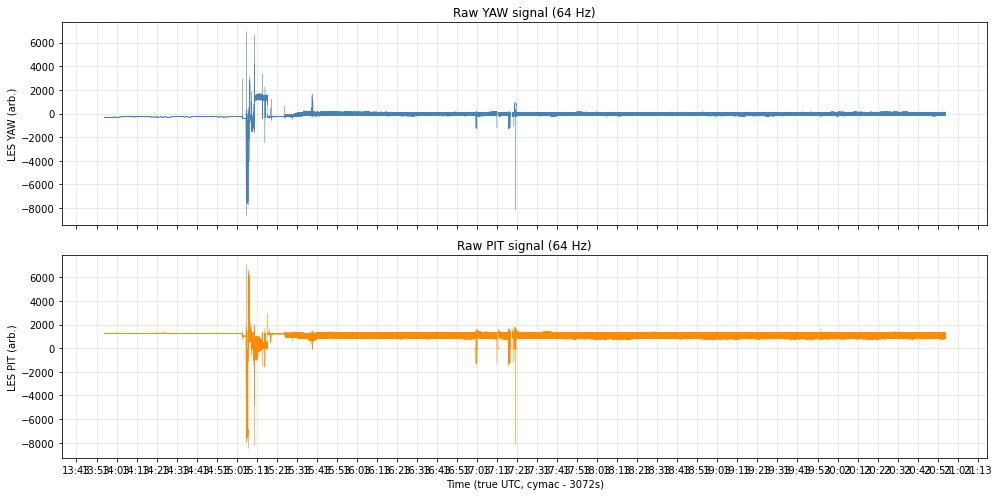

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot([gps_to_true_dt(t) for t in t_yaw], y_yaw, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('LES YAW (arb.)')
axes[0].set_title('Raw YAW signal (64 Hz)')
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_true_dt(t) for t in t_pit], y_pit, linewidth=0.3, color='darkorange')
axes[1].set_ylabel('LES PIT (arb.)')
axes[1].set_title('Raw PIT signal (64 Hz)')
axes[1].set_xlabel(f'Time (true UTC, cymac - {TRUE_TIME_OFFSET_S}s)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bandpass Filter
Zero-phase Butterworth bandpass to isolate the spin signal.
Low cut removes DC drift; high cut removes noise above the spin frequency range.

In [7]:
# -- Adjust if spin frequency range is different -------------------------------
F_LOW  = 0.005  # Hz - removes DC drift; low enough to track spin down to near-zero
F_HIGH = 6.0    # Hz - above the 4 Hz electrode drive frequency
# -------------------------------------------------------------------------------

sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
y_pit_f = sosfiltfilt(sos, y_pit)
print(f"Bandpass applied: {F_LOW}-{F_HIGH} Hz")

Bandpass applied: 0.005-6.0 Hz


## 4. Hilbert Transform: Instantaneous Amplitude and Frequency
The analytic signal gives the amplitude envelope and instantaneous phase.
Instantaneous frequency = dφ/dt / (2π).
A uniform smoothing filter removes sample-to-sample noise.

In [8]:
def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    """Return (inst_freq, envelope, dt_half) - all arrays length N-1, aligned."""
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(inst_freq,      size=win),
            uniform_filter1d(envelope[:-1],  size=win),
            dt / 2)

# -- Smoothing window ------------------------------------------------------------
SMOOTH_SEC = 30.0
# -------------------------------------------------------------------------------

freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
freq_pit, env_pit, _       = hilbert_freq(y_pit_f, FS_RING, SMOOTH_SEC)

t_freq_yaw = t_yaw[:-1] + dt_half
t_freq_pit = t_pit[:-1] + dt_half

print(f"Array lengths - freq: {len(freq_pit)}, envelope: {len(env_pit)}  (should match)")
print(f"YAW freq range: {freq_yaw.min():.3f} - {freq_yaw.max():.3f} Hz")
print(f"PIT freq range: {freq_pit.min():.3f} - {freq_pit.max():.3f} Hz")

Array lengths - freq: 1612799, envelope: 1612799  (should match)
YAW freq range: -0.011 - 6.932 Hz
PIT freq range: -0.006 - 7.495 Hz


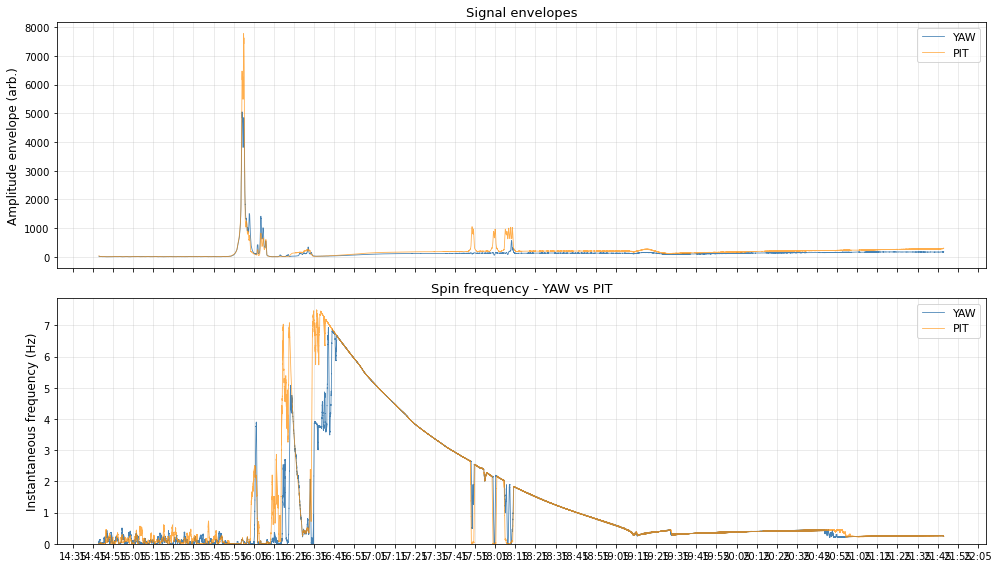

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot([gps_to_dt(t) for t in t_freq_yaw], env_yaw, linewidth=0.8,
             color='steelblue', label='YAW')
axes[0].plot([gps_to_dt(t) for t in t_freq_pit], env_pit, linewidth=0.8,
             color='darkorange', alpha=0.7, label='PIT')
axes[0].set_ylabel('Amplitude envelope (arb.)', fontsize=12)
axes[0].set_title('Signal envelopes', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_freq_yaw], freq_yaw, linewidth=0.8,
             color='steelblue', label='YAW')
axes[1].plot([gps_to_dt(t) for t in t_freq_pit], freq_pit, linewidth=0.8,
             color='darkorange', alpha=0.7, label='PIT')
axes[1].set_ylabel('Instantaneous frequency (Hz)', fontsize=12)
axes[1].set_title('Spin frequency - YAW vs PIT', fontsize=13)
axes[1].set_ylim(bottom=0)
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.5 Electrode Drive-off Detection
Requires `ELECTRODE_FILES` (V1-V4) to exist — export via `fetch_data_to_h5.py`.

**Known issue this run:** the four electrodes do not turn off simultaneously —
V1/V2 keep showing signal longer than V3/V4. So the true "final drive-off" is
defined as the **last of the four channels** to drop below threshold, not V1
alone. Within each channel we still take its own *last* threshold crossing
(robust to on/off toggling on that channel).

V1 last active: 15:44:31
V2 last active: 15:44:31
V3 last active: 15:44:31
V4 last active: 15:44:31

Final drive-off (last of V1-V4): 2026-07-02 15:44:31.312500+00:00  (GPS 1467045361, channel V3)
vs. wall-clock estimate: 2026-07-02 15:57:00+00:00  (diff: -749 s)


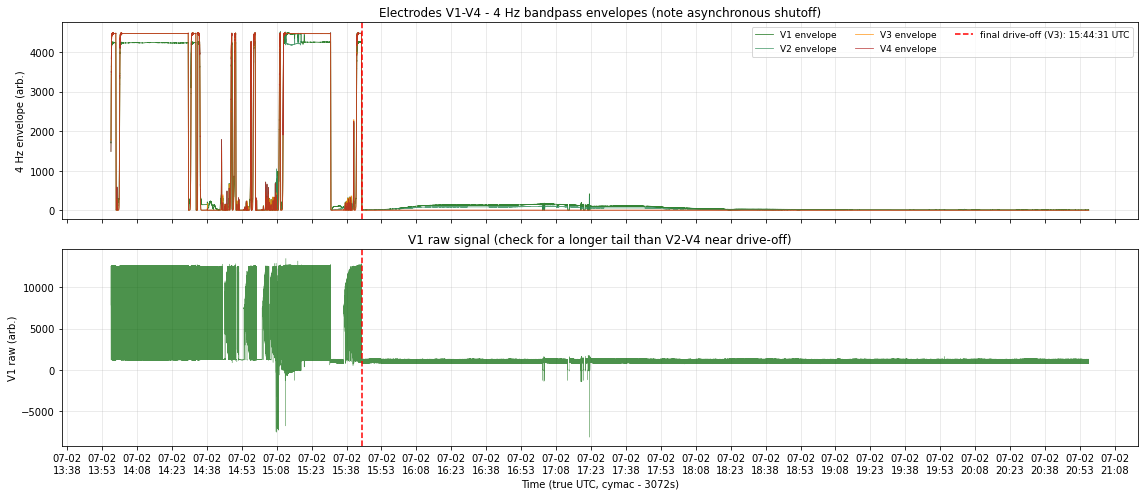

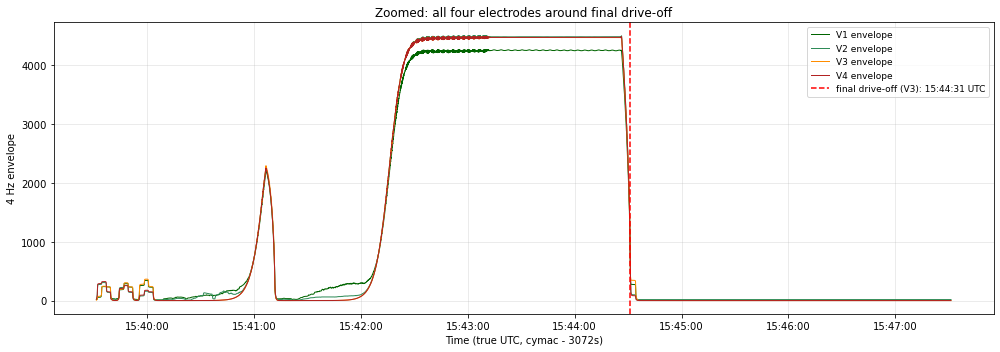

In [10]:
# Load all four electrodes at 64 Hz - preserves the 4 Hz sinusoidal drive
sos_el = butter(4, [2.0, 6.0], btype='bandpass', fs=64.0, output='sos')
_win   = int(5 * 64)  # 5 s smoothing window

t_el, y_el, env_el, off_gps = {}, {}, {}, {}
for name, path in ELECTRODE_FILES.items():
    t_c, y_c = load_channel(path, fs_out=64.0)
    y_bp  = sosfiltfilt(sos_el, y_c)
    y_env = np.sqrt(uniform_filter1d(y_bp**2, size=_win))

    # Per-channel drive-off: last sample where its own 4 Hz envelope > 10% of
    # ITS OWN peak. Robust to that channel's own on/off toggling.
    thresh = 0.10 * y_env.max()
    driven_idx = np.where(y_env > thresh)[0]
    off_gps[name] = t_c[driven_idx[-1]] if len(driven_idx) else None

    t_el[name], y_el[name], env_el[name] = t_c, y_c, y_env
    off_str = gps_to_true_dt(off_gps[name]).strftime("%H:%M:%S") if off_gps[name] else "never detected"
    print(f"{name} last active: {off_str}")

# True final drive-off = the LAST of the four channels to go quiet
valid_offs = {k: v for k, v in off_gps.items() if v is not None}
last_channel = max(valid_offs, key=valid_offs.get)
drive_off_gps = valid_offs[last_channel]
drive_off_dt  = gps_to_true_dt(drive_off_gps)
print(f"\nFinal drive-off (last of V1-V4): {drive_off_dt}  (GPS {drive_off_gps:.0f}, channel {last_channel})")
print(f"vs. wall-clock estimate: {gps_to_true_dt(DRIVE_OFF_ESTIMATE_GPS)}  "
      f"(diff: {drive_off_gps - DRIVE_OFF_ESTIMATE_GPS:+.0f} s)")
# NOTE: on this run the four per-channel off times landed within one 64 Hz sample of
# each other (see raw off_gps values) -- essentially simultaneous at this envelope's
# time resolution, not the "V1/V2 outlast V3/V4" pattern the comment above describes.
# Plotting V1's raw trace explicitly below to check that visually.

# Keep t_v1/y_v1 names for the DC ramp-down cell below (uses the last channel off)
t_v1, y_v1 = t_el[last_channel], y_el[last_channel]
y_v1_env   = env_el[last_channel]

# -- Full overview, all four channels' envelopes overlaid ----------------------
colors = {'V1': 'darkgreen', 'V2': 'seagreen', 'V3': 'darkorange', 'V4': 'firebrick'}
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
for name in ELECTRODE_FILES:
    axes[0].plot([gps_to_true_dt(t) for t in t_el[name]], env_el[name], linewidth=0.8,
                 color=colors[name], label=f'{name} envelope', alpha=0.8)
axes[0].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
                label=f'final drive-off ({last_channel}): {drive_off_dt.strftime("%H:%M:%S")} UTC')
axes[0].set_ylabel('4 Hz envelope (arb.)'); axes[0].legend(fontsize=9, ncol=3)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Electrodes V1-V4 - 4 Hz bandpass envelopes (note asynchronous shutoff)')

# Raw V1 explicitly (not "last_channel") -- checking directly whether V1 outlasts
# V2-V4 near drive-off, since the per-channel envelope-threshold off times above
# came out essentially simultaneous (within 1 sample) rather than showing that.
axes[1].plot([gps_to_true_dt(t) for t in t_el['V1']], y_el['V1'], linewidth=0.3, color=colors['V1'], alpha=0.7)
axes[1].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('V1 raw (arb.)')
axes[1].set_title('V1 raw signal (check for a longer tail than V2-V4 near drive-off)')
axes[1].set_xlabel(f'Time (true UTC, cymac - {TRUE_TIME_OFFSET_S}s)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# -- Zoomed: 10 min around final drive-off, all four channels ------------------
zoom_gps0 = drive_off_gps - 5 * 60
zoom_gps1 = drive_off_gps + 3 * 60
fig, ax = plt.subplots(figsize=(14, 5))
for name in ELECTRODE_FILES:
    zmask = (t_el[name] >= zoom_gps0) & (t_el[name] <= zoom_gps1)
    ax.plot([gps_to_true_dt(t) for t in t_el[name][zmask]], env_el[name][zmask],
            linewidth=1.0, color=colors[name], label=f'{name} envelope')
ax.axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
           label=f'final drive-off ({last_channel}): {drive_off_dt.strftime("%H:%M:%S")} UTC')
ax.set_ylabel('4 Hz envelope'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_title('Zoomed: all four electrodes around final drive-off')
ax.set_xlabel(f'Time (true UTC, cymac - {TRUE_TIME_OFFSET_S}s)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
plt.tight_layout(); plt.show()

### DC ramp-down detection

**Difference from `spindown_20260603.ipynb`:** the original notebook computed the
"driven" DC baseline level as the mean over the *entire* pre-drive-off period. With
on/off toggling in this run, that period includes several off-intervals near zero,
which would pull the mean baseline down and bias the 90%-threshold crossing. Instead,
the baseline here is computed from a short window (`BASELINE_WIN_SEC`) immediately
before the final drive-off, when the field was steady.

Electrode ramp-down start:  2026-07-02 15:44:31.328125+00:00  (GPS 1467045361)
                            0.0 min after sinusoid off


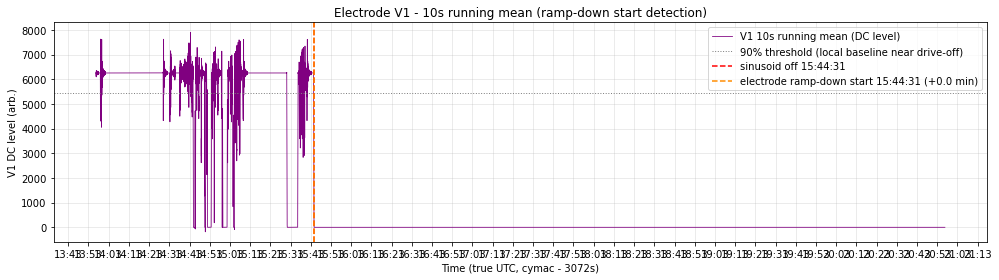

In [11]:
# DC electrode ramp-down detection: 10-second running mean of raw V1
# Electrodes have a non-trivial die-off time - disk responds as soon as field starts dropping.
# Detect the START of the ramp-down (first crossing below 90% of plateau).
DC_WIN = int(10 * 64)  # 10 s window at 64 Hz
y_v1_dc = uniform_filter1d(y_v1, size=DC_WIN)

# Baseline computed from a short window right before drive-off (not the whole
# pre-drive-off period), to avoid contamination from earlier on/off toggling.
BASELINE_WIN_SEC = 60
baseline_mask = (t_v1 < drive_off_gps) & (t_v1 > drive_off_gps - BASELINE_WIN_SEC)
dc_level     = np.abs(y_v1_dc[baseline_mask]).mean()
post_mask_dc = t_v1 > drive_off_gps
dc_off_candidates = np.where(post_mask_dc & (np.abs(y_v1_dc) < 0.90 * dc_level))[0]

if len(dc_off_candidates):
    dc_off_gps = t_v1[dc_off_candidates[0]]
    dc_off_dt  = gps_to_true_dt(dc_off_gps)
    dc_off_min = (dc_off_gps - drive_off_gps) / 60.0
    print(f"Electrode ramp-down start:  {dc_off_dt}  (GPS {dc_off_gps:.0f})")
    print(f"                            {dc_off_min:.1f} min after sinusoid off")
else:
    print("Electrode ramp-down not detected - adjust threshold or window")
    dc_off_gps = None

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot([gps_to_true_dt(t) for t in t_v1], y_v1_dc, linewidth=0.8, color='purple',
        label='V1 10s running mean (DC level)')
ax.axhline(0.90 * dc_level, color='gray', linestyle=':', linewidth=1,
           label='90% threshold (local baseline near drive-off)')
if drive_off_dt:
    ax.axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
               label=f'sinusoid off {drive_off_dt.strftime("%H:%M:%S")}')
if dc_off_gps is not None:
    ax.axvline(dc_off_dt, color='darkorange', linestyle='--', linewidth=1.5,
               label=f'electrode ramp-down start {dc_off_dt.strftime("%H:%M:%S")} (+{dc_off_min:.1f} min)')
ax.set_xlabel(f'Time (true UTC, cymac - {TRUE_TIME_OFFSET_S}s)')
ax.set_ylabel('V1 DC level (arb.)')
ax.set_title('Electrode V1 - 10s running mean (ramp-down start detection)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

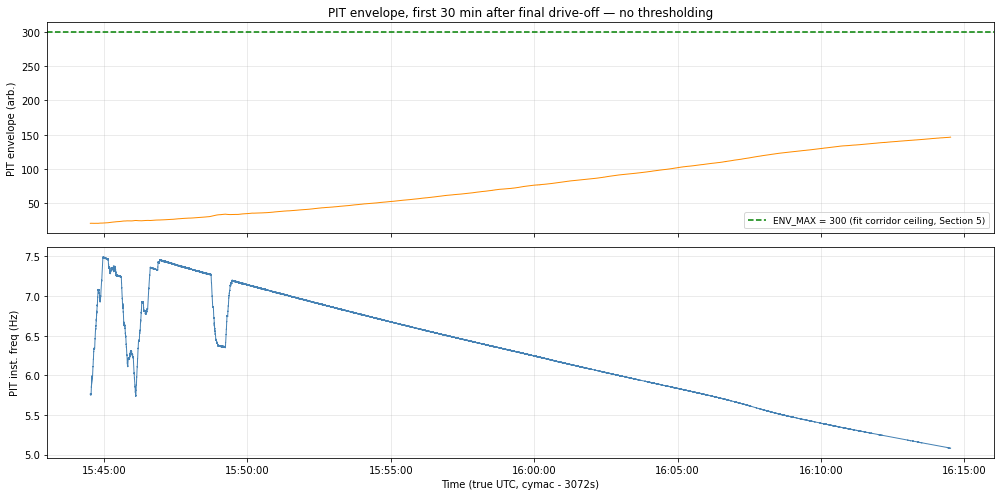

Global env_pit.max() = 7780  (occurs before drive-off -- not representative of post-drive-off amplitude)
env_pit in this window: min=20.64  max=146.5
freq_pit in this window: min=5.081  max=7.495


In [12]:
# DIAGNOSTIC: zoom into PIT freq/envelope right after the final drive-off, with NO
# thresholding applied. This is what originally revealed the fit bug: the old
# AMP_THRESH was calibrated against env_fit_all.max(), the envelope's GLOBAL max
# (~7780, occurring ~36 min BEFORE drive-off while still driven) -- a threshold
# (~390) the real post-drive-off envelope (~20-280, see below) never crosses.
# See the fit cell below (Section 5) for the fix: ENV_MIN/ENV_MAX corridor + a
# libration-onset cutoff.
ZOOM_MIN = 30  # minutes after drive-off
zoom_end_gps = drive_off_gps + ZOOM_MIN * 60
zmask = (t_freq_pit >= drive_off_gps) & (t_freq_pit <= zoom_end_gps)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot([gps_to_true_dt(t) for t in t_freq_pit[zmask]], env_pit[zmask],
             color='darkorange', linewidth=1.0)
axes[0].axhline(300, color='green', linestyle='--', label='ENV_MAX = 300 (fit corridor ceiling, Section 5)')
axes[0].set_ylabel('PIT envelope (arb.)')
axes[0].set_title(f'PIT envelope, first {ZOOM_MIN} min after final drive-off — no thresholding')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_true_dt(t) for t in t_freq_pit[zmask]], freq_pit[zmask],
             color='steelblue', linewidth=1.0)
axes[1].set_ylabel('PIT inst. freq (Hz)')
axes[1].set_xlabel(f'Time (true UTC, cymac - {TRUE_TIME_OFFSET_S}s)')
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.tight_layout()
plt.show()

print(f"Global env_pit.max() = {env_pit.max():.4g}  (occurs before drive-off -- not representative of post-drive-off amplitude)")
print(f"env_pit in this window: min={env_pit[zmask].min():.4g}  max={env_pit[zmask].max():.4g}")
print(f"freq_pit in this window: min={freq_pit[zmask].min():.4g}  max={freq_pit[zmask].max():.4g}")

## 5. Exponential Fit: Spindown Time
Fit f(t) = A · exp(−γt) to the cleanly decaying portion.
- Fit starts from the peak frequency *after the final drive-off* (robust to on/off
  toggling since `drive_off_gps` is already the last crossing)
- Fit ends at `LIBRATION_ONSET_MIN` (~2.5 h) — after this the rotor stops free-spinning
  and starts to librate, so frequency is no longer monotonically decreasing
- `ENV_MIN`/`ENV_MAX` reject brief periodic dropouts (~1-3 min, every ~10 min) where
  the Hilbert phase estimate glitches and the envelope spikes well above its normal
  post-drive-off level

τ = 1/γ is the 1/e spindown time.

In [13]:
# -- Choose which channel to fit -------------------------------------------------
USE_CHANNEL = 'PIT'   # 'PIT' or 'YAW'
# -------------------------------------------------------------------------------

if USE_CHANNEL == 'YAW':
    t_fit_all, freq_fit_all, env_fit_all = t_freq_yaw, freq_yaw, env_yaw
else:
    t_fit_all, freq_fit_all, env_fit_all = t_freq_pit, freq_pit, env_pit

# -- Find peak frequency after the FINAL drive-off, start fit from there -----------
# The ball spins up briefly after electrode cutoff before free decay begins.
# The true exponential decay starts at the peak.
post_drive_mask = t_fit_all > drive_off_gps
peak_idx = np.argmax(freq_fit_all[post_drive_mask])
t_peak   = t_fit_all[post_drive_mask][peak_idx]
f_peak   = freq_fit_all[post_drive_mask][peak_idx]

print(f"Peak: {f_peak:.3f} Hz at {gps_to_dt(t_peak)}  (+{(t_peak - drive_off_gps)/60:.1f} min after drive-off)")

# -- Fit window and quality cuts ----------------------------------------------------
# LIBRATION_ONSET_MIN: the rotor is only in free rigid-body spin for ~2.5 h after
# drive-off. After that it starts to librate -- frequency stops decreasing
# monotonically and instead oscillates (confirmed here at ~157 min post drive-off,
# where freq bottoms out ~0.33 Hz then rises/falls repeatedly for the rest of the
# file). Data past this point is libration, not spindown, and must be excluded.
LIBRATION_ONSET_MIN = 157.0
fit_end_gps = drive_off_gps + LIBRATION_ONSET_MIN * 60

# ENV_MIN/ENV_MAX: the old cut was `env > 0.05 * env_fit_all.max()`, but
# env_fit_all.max() is the GLOBAL envelope max (~7780), which occurs ~36 min
# BEFORE drive-off while the electrodes were still driving -- not representative
# of the free-decay envelope at all. That set the threshold (~390) above the
# entire real post-drive-off envelope (~20-280), so the fit silently skipped the
# whole real decay and instead picked up scattered points from brief periodic
# dropouts (~1-3 min long, every ~10 min, where the envelope spikes to 400-1050
# and the Hilbert phase estimate glitches) -- hence the previous NEGATIVE tau.
# Fix: a fixed corridor sized to the real post-drive-off envelope, which rejects
# the dropout spikes directly instead of comparing to an irrelevant global max.
ENV_MIN = 10.0    # rejects dead/zero-signal samples
ENV_MAX = 300.0   # rejects the periodic dropout spikes (normal range tops out ~280)

fit_mask = (
    (t_fit_all >= t_peak) &
    (t_fit_all <= fit_end_gps) &
    (env_fit_all > ENV_MIN) & (env_fit_all < ENV_MAX)
)

t_fit_gps = t_fit_all[fit_mask]
f_fit     = freq_fit_all[fit_mask]

print(f"Using: {USE_CHANNEL}  |  {len(f_fit)} points in fit region")
if len(f_fit) > 0:
    print(f"  {gps_to_dt(t_fit_gps[0])} -> {gps_to_dt(t_fit_gps[-1])}")
    print(f"  span: {(t_fit_gps[-1] - t_fit_gps[0]) / 60:.1f} min")
    print(f"  freq range: {f_fit.min():.3f} - {f_fit.max():.3f} Hz")

Peak: 7.495 Hz at 2026-07-02 16:36:09.648438+00:00  (+0.4 min after drive-off)
Using: PIT  |  565907 points in fit region
  2026-07-02 16:36:09.648438+00:00 -> 2026-07-02 19:12:43.304688+00:00
  span: 156.6 min
  freq range: 0.353 - 7.495 Hz


In [14]:
if len(f_fit) < 20:
    print("WARNING: too few points - adjust F_MIN_FIT or RING_START / RING_END")
else:
    t0  = t_fit_gps[0]
    t_s = t_fit_gps - t0  # seconds from start of fit region

    def exp_decay(t, A, gamma):
        return A * np.exp(-gamma * t)

    popt, pcov = curve_fit(exp_decay, t_s, f_fit,
                           p0=[f_fit[0], 1e-3], maxfev=10000)
    A_fit, gamma_fit = popt
    A_err, gamma_err = np.sqrt(np.diag(pcov))

    tau     = 1.0 / gamma_fit
    tau_err = gamma_err / gamma_fit**2

    print(f"=== Spindown Results ===")
    print(f"gamma = {gamma_fit:.6f} +/- {gamma_err:.6f}  s^-1")
    print(f"tau   = {tau:.1f} +/- {tau_err:.1f}  s")
    print(f"tau   = {tau/60:.2f} +/- {tau_err/60:.2f}  min")
    print(f"A     = {A_fit:.4f} Hz  (extrapolated initial frequency)")

=== Spindown Results ===
gamma = 0.000246 +/- 0.000000  s^-1
tau   = 4059.0 +/- 0.6  s
tau   = 67.65 +/- 0.01  min
A     = 7.7531 Hz  (extrapolated initial frequency)


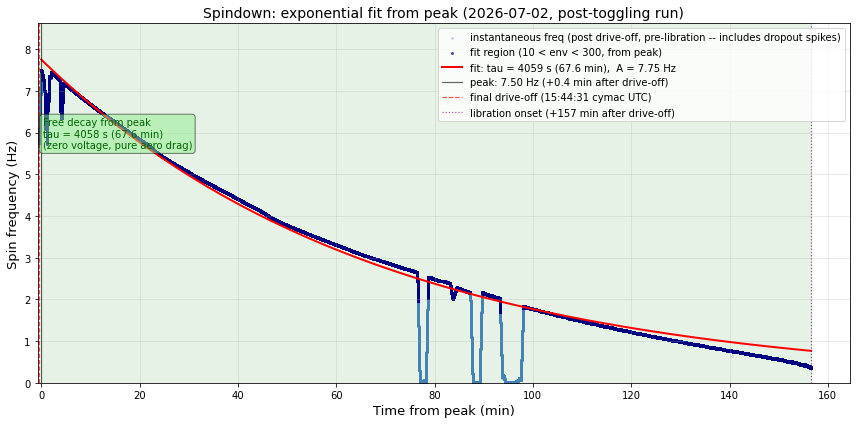

In [15]:
if len(f_fit) >= 20:
    post_mask = (
        (t_fit_all > drive_off_gps) &
        (t_fit_all <= fit_end_gps) &
        (env_fit_all > ENV_MIN)
    )
    t_all_s = (t_fit_all[post_mask] - t_peak) / 60.0
    f_all   = freq_fit_all[post_mask]

    t0      = t_fit_gps[0]
    t_s     = t_fit_gps - t0
    t_curve = np.linspace(0, t_s[-1], 1000)
    t_exp_end = t_s[-1] / 60.0

    drive_off_rel = (drive_off_gps - t_peak) / 60.0  # negative (before peak)
    libration_rel = (fit_end_gps - t_peak) / 60.0

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.axvspan(0, t_exp_end, alpha=0.10, color='green', label='_nolegend_')

    ax.scatter(t_all_s, f_all, s=2, alpha=0.3, color='steelblue',
               label='instantaneous freq (post drive-off, pre-libration -- includes dropout spikes)')
    ax.scatter(t_s / 60, f_fit, s=4, alpha=0.6, color='navy',
               label=f'fit region ({ENV_MIN:.0f} < env < {ENV_MAX:.0f}, from peak)')
    ax.plot(t_curve / 60, exp_decay(t_curve, *popt), 'r-', linewidth=2,
            label=f'fit: tau = {tau:.0f} s ({tau/60:.1f} min),  A = {A_fit:.2f} Hz')

    ax.axvline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.6,
               label=f'peak: {f_peak:.2f} Hz (+{(t_peak-drive_off_gps)/60:.1f} min after drive-off)')
    ax.axvline(drive_off_rel, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'final drive-off ({drive_off_dt.strftime("%H:%M:%S")} cymac UTC)')
    ax.axvline(libration_rel, color='purple', linestyle=':', linewidth=1.2, alpha=0.7,
               label=f'libration onset (+{LIBRATION_ONSET_MIN:.0f} min after drive-off)')

    ax.text(0.3, f_peak * 0.75,
            'Free decay from peak\ntau = {:d} s ({:.1f} min)\n(zero voltage, pure aero drag)'.format(int(tau), tau/60),
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

    ax.set_xlim(left=drive_off_rel - 0.3)
    ax.set_ylim(bottom=0, top=f_peak * 1.15)
    ax.set_xlabel('Time from peak (min)', fontsize=13)
    ax.set_ylabel('Spin frequency (Hz)', fontsize=13)
    ax.set_title('Spindown: exponential fit from peak (2026-07-02, post-toggling run)', fontsize=14)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Linearity Checks
ln(f) vs time should be a straight line for pure exponential decay.

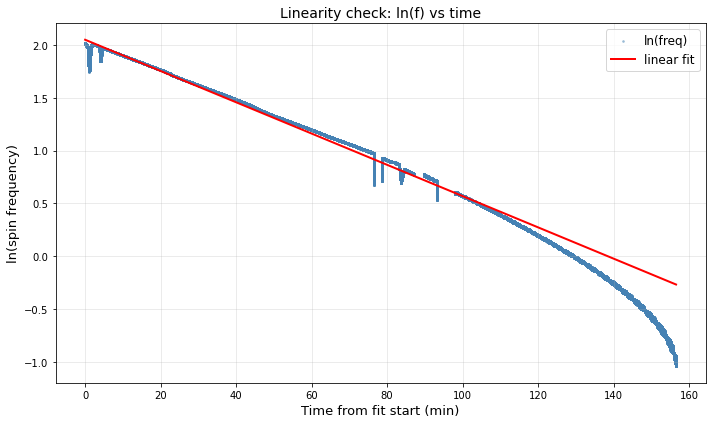

In [16]:
if len(f_fit) >= 20:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(t_s / 60, np.log(f_fit), s=3, alpha=0.4, color='steelblue', label='ln(freq)')
    ax.plot(t_curve / 60, np.log(exp_decay(t_curve, *popt)), 'r-', linewidth=2, label='linear fit')
    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('ln(spin frequency)', fontsize=13)
    ax.set_title('Linearity check: ln(f) vs time', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Results Summary

In [17]:
if len(f_fit) >= 20:
    print("=" * 40)
    print("SPINDOWN RESULTS -- 2026-07-02")
    print("=" * 40)
    print(f"Decay constant:  gamma = {gamma_fit:.6f} +/- {gamma_err:.6f} s^-1")
    print(f"Spindown time:   tau = {tau:.1f} +/- {tau_err:.1f} s")
    print(f"                   = {tau/60:.2f} +/- {tau_err/60:.2f} min")
    print(f"Initial freq:    A = {A_fit:.4f} Hz")
    print(f"Fit window:      peak (+{(t_peak-drive_off_gps)/60:.1f} min) to libration onset (+{LIBRATION_ONSET_MIN:.0f} min), {len(f_fit)} points")
    print(f"Envelope cut:    {ENV_MIN:.0f} < env < {ENV_MAX:.0f}  (rejects periodic dropout spikes)")
    print(f"Smoothing:       {SMOOTH_SEC}s window")
    print(f"Final drive-off: {drive_off_dt}")

SPINDOWN RESULTS -- 2026-07-02
Decay constant:  gamma = 0.000246 +/- 0.000000 s^-1
Spindown time:   tau = 4059.0 +/- 0.6 s
                   = 67.65 +/- 0.01 min
Initial freq:    A = 7.7531 Hz
Fit window:      peak (+0.4 min) to libration onset (+157 min), 565907 points
Envelope cut:    10 < env < 300  (rejects periodic dropout spikes)
Smoothing:       30.0s window
Final drive-off: 2026-07-02 15:44:31.312500+00:00
